In [1]:

# Install dependencies (only needed once per Colab session)
!pip install -q torch transformers pandas matplotlib seaborn

import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, DynamicCache
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PERMANENT GITHUB RENDER FIX ---
# Disable Hugging Face graphical progress bars so Colab doesn't inject corrupted widget metadata.
transformers.utils.logging.disable_progress_bar()
# -----------------------------------

# 1. Initialization
model_name = "gpt2"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing {model_name} on {device}...")

# 2. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# 3. Load Model to GPU
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

print("Environment and Model are ready!")


C:\Users\Fareed Durgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


Initializing gpt2 on cpu...


C:\Users\Fareed Durgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Fareed Durgam\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Environment and Model are ready!


In [2]:
def count_tensor_bytes(obj):
    """Recursively walks through any Hugging Face cache structure to sum up tensor bytes."""
    # if the obj is a raw tensor
    if isinstance(obj, torch.Tensor):
        return obj.nelement() * obj.element_size()
    # else if the obj is list ot tuple of tensors
    elif isinstance(obj, (tuple, list)):
        return sum(count_tensor_bytes(x) for x in obj)
    # else if the obj has a method called '__iter__'
    elif hasattr(obj, '__iter__'):
        return sum(count_tensor_bytes(x) for x in obj)
    return 0

def run_controlled_benchmark():
    batch_sizes = [1, 4, 8, 16]
    sequence_lengths = [32, 64, 128]
    base_prompt = "This is the begining of a base promt, After this we have"
    results = []

    # Get total GPU VRAM for percentage calculations
    # Only attempt to get CUDA properties if device is CUDA
    total_vram_mb = 0
    if device == "cuda":
        total_vram_mb = torch.cuda.get_device_properties(device).total_memory / (1024 * 1024)

    print("-" * 110)
    print(f"{'Batch':<8} | {'Seq':<8} | {'Latency':<8} | {'Throughput':<11} | {'Peak VRAM':<10} | {'KV Cache':<10} | {'VRAM %':<8} | {'Compute %'}")
    print("-" * 110)

    for batch_size in batch_sizes:
        for seq_len in sequence_lengths:
            prompts = [base_prompt] * batch_size
            inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
            input_ids = inputs.input_ids

            if device == "cuda":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats()

            my_kv_cache = DynamicCache()

            # List to store GPU compute utilization samples during the loop
            compute_samples = []

            start_time = time.perf_counter()

            with torch.no_grad():
                # 1. PREFILL PHASE
                outputs = model(input_ids=input_ids, past_key_values=my_kv_cache, use_cache=True)
                my_kv_cache = outputs.past_key_values
                next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
                generated_tokens = 1

                # 2. DECODE PHASE
                for _ in range(seq_len - 1):
                    outputs = model(input_ids=next_token, past_key_values=my_kv_cache, use_cache=True)
                    my_kv_cache = outputs.past_key_values
                    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
                    generated_tokens += 1

                    # Sample the GPU compute core utilization
                    if device == "cuda":
                        compute_samples.append(torch.cuda.utilization())

            end_time = time.perf_counter()

            # Calculate Metrics
            peak_memory_mb = 0
            vram_util_percent = 0
            avg_compute_util = 0

            if device == "cuda":
                peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)
                vram_util_percent = (peak_memory_mb / total_vram_mb) * 100 if total_vram_mb > 0 else 0
                avg_compute_util = sum(compute_samples) / len(compute_samples) if compute_samples else 0

            kv_cache_mb = count_tensor_bytes(my_kv_cache) / (1024 * 1024)

            latency = end_time - start_time
            throughput = (generated_tokens * batch_size) / latency

            print(f"{batch_size:<8} | {seq_len:<8} | {latency:<8.4f} | {throughput:<11.2f} | {peak_memory_mb:<10.2f} | {kv_cache_mb:<10.2f} | {vram_util_percent:<8.2f} | {avg_compute_util:<8.2f}")

            results.append({
                "Batch Size": batch_size,
                "Sequence Length": seq_len,
                "Latency (s)": latency,
                "Throughput (tok/s)": throughput,
                "Peak VRAM (MB)": peak_memory_mb,
                "KV Cache (MB)": kv_cache_mb,
                "VRAM Util (%)": vram_util_percent,
                "Compute Util (%)": avg_compute_util
            })

            del inputs, input_ids, outputs, next_token, my_kv_cache

    return pd.DataFrame(results)

df_baseline_results = run_controlled_benchmark()

--------------------------------------------------------------------------------------------------------------
Batch    | Seq      | Latency  | Throughput  | Peak VRAM  | KV Cache   | VRAM %   | Compute %
--------------------------------------------------------------------------------------------------------------
1        | 32       | 2.4187   | 13.23       | 0.00       | 3.23       | 0.00     | 0.00    
1        | 64       | 3.3342   | 19.20       | 0.00       | 5.48       | 0.00     | 0.00    
1        | 128      | 7.0086   | 18.26       | 0.00       | 9.98       | 0.00     | 0.00    
4        | 32       | 2.0310   | 63.02       | 0.00       | 12.94      | 0.00     | 0.00    
4        | 64       | 4.0020   | 63.97       | 0.00       | 21.94      | 0.00     | 0.00    
4        | 128      | 8.8969   | 57.55       | 0.00       | 39.94      | 0.00     | 0.00    
8        | 32       | 3.3882   | 75.56       | 0.00       | 25.88      | 0.00     | 0.00    
8        | 64       | 6.9878   | 

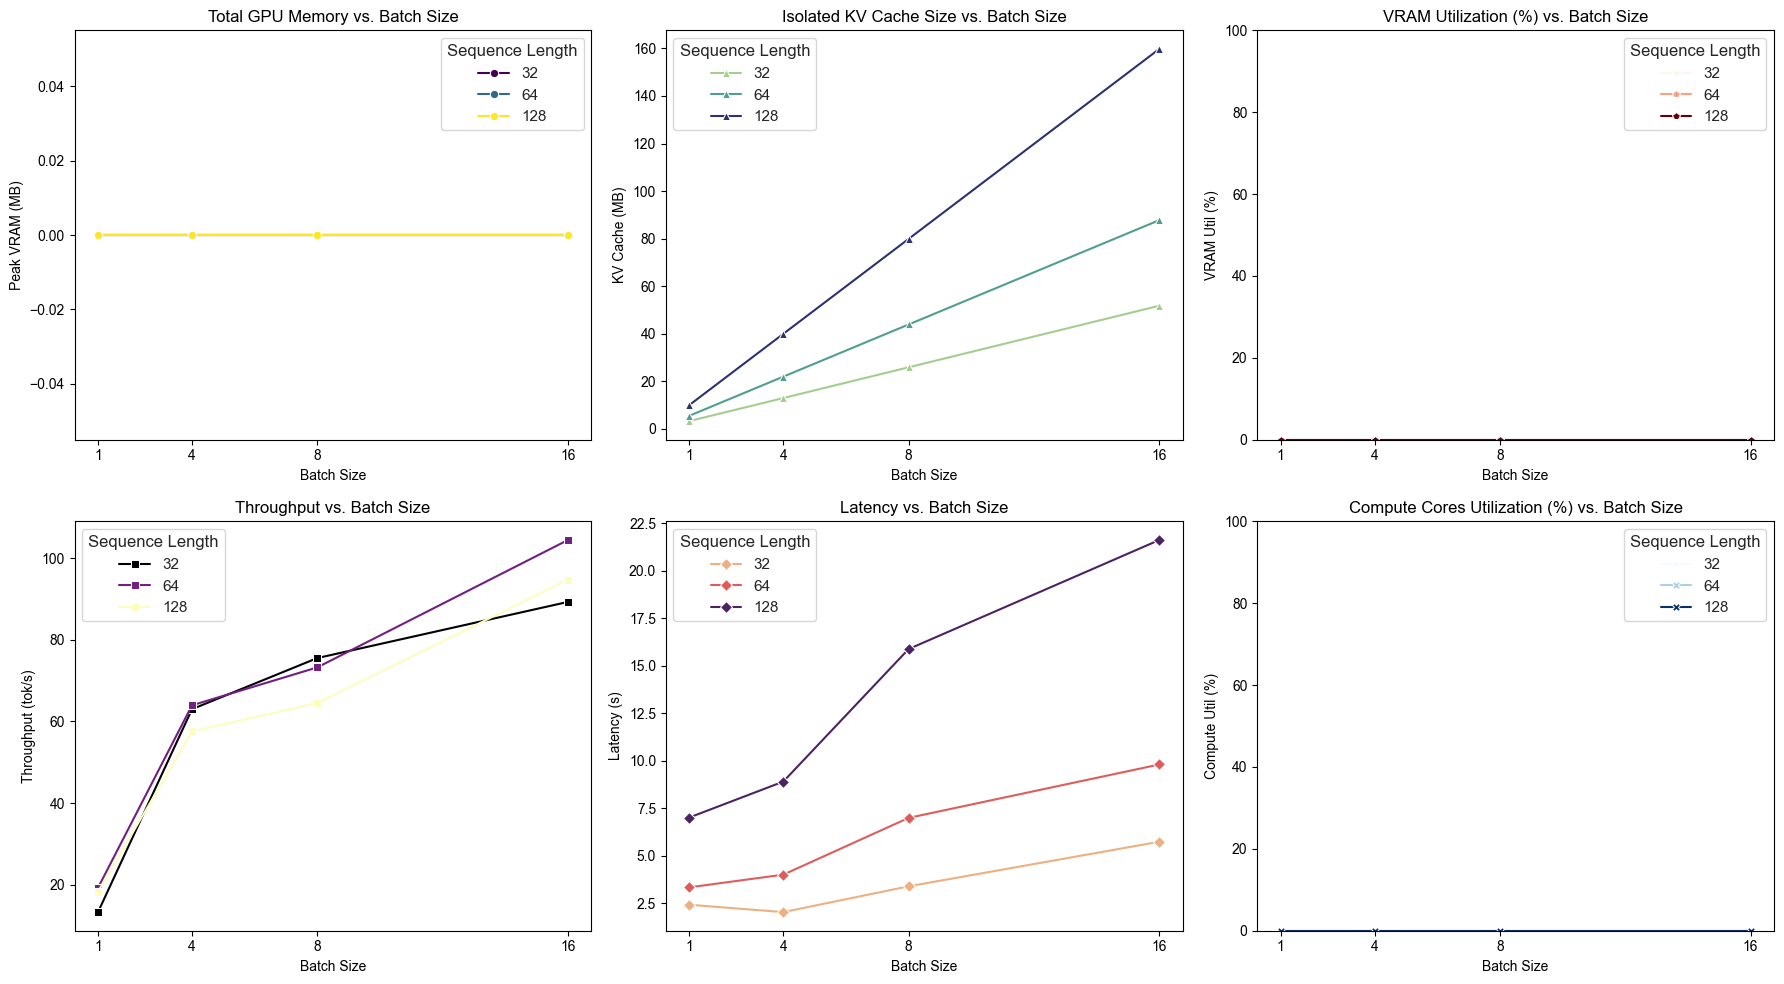

In [3]:
def plot_baseline_results(df):
    # Expanded to a 2x3 grid to fit the new utilization metrics
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    sns.set_theme(style="whitegrid")

    # Plot 1: Total Peak VRAM
    sns.lineplot(data=df, x="Batch Size", y="Peak VRAM (MB)", hue="Sequence Length", marker="o", palette="viridis", ax=axes[0, 0])
    axes[0, 0].set_title("Total GPU Memory vs. Batch Size")
    axes[0, 0].set_xticks(df["Batch Size"].unique())

    # Plot 2: Isolated KV Cache Size
    sns.lineplot(data=df, x="Batch Size", y="KV Cache (MB)", hue="Sequence Length", marker="^", palette="crest", ax=axes[0, 1])
    axes[0, 1].set_title("Isolated KV Cache Size vs. Batch Size")
    axes[0, 1].set_xticks(df["Batch Size"].unique())

    # Plot 3: VRAM Utilization Percentage
    sns.lineplot(data=df, x="Batch Size", y="VRAM Util (%)", hue="Sequence Length", marker="p", palette="Reds", ax=axes[0, 2])
    axes[0, 2].set_title("VRAM Utilization (%) vs. Batch Size")
    axes[0, 2].set_ylim(0, 100) # Lock Y-axis to 100%
    axes[0, 2].set_xticks(df["Batch Size"].unique())

    # Plot 4: Throughput
    sns.lineplot(data=df, x="Batch Size", y="Throughput (tok/s)", hue="Sequence Length", marker="s", palette="magma", ax=axes[1, 0])
    axes[1, 0].set_title("Throughput vs. Batch Size")
    axes[1, 0].set_xticks(df["Batch Size"].unique())

    # Plot 5: Latency
    sns.lineplot(data=df, x="Batch Size", y="Latency (s)", hue="Sequence Length", marker="D", palette="flare", ax=axes[1, 1])
    axes[1, 1].set_title("Latency vs. Batch Size")
    axes[1, 1].set_xticks(df["Batch Size"].unique())

    # Plot 6: Compute Utilization Percentage
    sns.lineplot(data=df, x="Batch Size", y="Compute Util (%)", hue="Sequence Length", marker="X", palette="Blues", ax=axes[1, 2])
    axes[1, 2].set_title("Compute Cores Utilization (%) vs. Batch Size")
    axes[1, 2].set_ylim(0, 100) # Lock Y-axis to 100%
    axes[1, 2].set_xticks(df["Batch Size"].unique())

    plt.tight_layout()
    plt.show()

# Generate the 6 plots
plot_baseline_results(df_baseline_results)

DEJAVU SIMULATION: KV Cache Transfer Utilities

This section defines helper functions which is used to simulate DejaVu-style KV cache streaming.  
The functions move KV cache tensors between CPU and GPU memory tiers and measure the transfer time.

We also include a utility to estimate the memory footprint of KV cache tensors during the inference process.  
These utilities allow us to simulate KV cache movement during decoding and analyze the overhead introduced by KV streaming.

In [19]:
import psutil
import os

def count_tensor_bytes(obj):
    """Must count bytes used by tensors inside cache structures."""
    if isinstance(obj, torch.Tensor):
        return obj.nelement() * obj.element_size()

    if isinstance(obj, DynamicCache):
        if hasattr(obj, "to_legacy_cache"):
            return count_tensor_bytes(obj.to_legacy_cache())
        return 0

    if isinstance(obj, (tuple, list)):
        return sum(count_tensor_bytes(x) for x in obj)

    return 0


def move_nested_to_device(obj, target_device):
    """Recursively move tensors in nested tuples/lists to a target device."""
    if isinstance(obj, torch.Tensor):
        return obj.to(target_device)

    if isinstance(obj, tuple):
        return tuple(move_nested_to_device(x, target_device) for x in obj)

    if isinstance(obj, list):
        return [move_nested_to_device(x, target_device) for x in obj]

    return obj


def move_kv_to_cpu_timed(kv_cache):
    """Move cache to CPU while preserving DynamicCache type."""
    start = time.perf_counter()

    legacy_cache = kv_cache.to_legacy_cache() if hasattr(kv_cache, "to_legacy_cache") else kv_cache
    legacy_cache_cpu = move_nested_to_device(legacy_cache, "cpu")

    if hasattr(DynamicCache, "from_legacy_cache"):
        new_cache = DynamicCache.from_legacy_cache(legacy_cache_cpu)
    else:
        new_cache = legacy_cache_cpu

    end = time.perf_counter()
    return new_cache, (end - start)


def move_kv_to_gpu_timed(kv_cache):
    """Move cache to GPU while preserving DynamicCache type."""
    start = time.perf_counter()

    legacy_cache = kv_cache.to_legacy_cache() if hasattr(kv_cache, "to_legacy_cache") else kv_cache
    legacy_cache_gpu = move_nested_to_device(legacy_cache, device)

    if hasattr(DynamicCache, "from_legacy_cache"):
        new_cache = DynamicCache.from_legacy_cache(legacy_cache_gpu)
    else:
        new_cache = legacy_cache_gpu

    end = time.perf_counter()
    return new_cache, (end - start)

DEJAVU KV CACHE STREAMING SIMULATION: 
In this phase we simulate a DejaVu-style inference pipeline where KV cache entries are stored in CPU memory and streamed to the GPU during decoding process.

For each decoding step we have:
1. KV cache is transferred from CPU to GPU
2. The model generates the next token
3. Updated KV cache is moved back to CPU

This allows us to measure the performance overhead introduced by KV cache streaming.

In [29]:
def run_dejavu_benchmark():
    """
    This simulates the DejaVu KV streaming system.
    KV cache is moved to CPU memory after prefill process and then streamed
    then back to GPU during decoding process.
    """
    batch_sizes = [1, 4, 8, 16]
    sequence_lengths = [32, 64, 128]
    base_prompt = "This is the beginning of a base prompt, after this we have"

    results = []

    total_vram_mb = 0
    if device == "cuda":
        total_vram_mb = torch.cuda.get_device_properties(device).total_memory / (1024 * 1024)

    process = psutil.Process(os.getpid())

    print("-" * 170)
    print(f"{'Batch':<8} | {'Seq':<8} | {'Latency':<10} | {'Throughput':<10} | {'Transfer':<10} | {'Overhead %':<10} | {'Peak VRAM':<10} | {'CPU RAM':<10}")
    print("-" * 170)

    for batch_size in batch_sizes:
        for seq_len in sequence_lengths:
            prompts = [base_prompt] * batch_size
            inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
            input_ids = inputs.input_ids

            if device == "cuda":
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats()

            kv_cache = DynamicCache()
            transfer_time = 0.0
            generated_tokens = 0

            total_start = time.perf_counter()

            with torch.no_grad():
                # Prefill phase
                outputs = model(input_ids=input_ids, past_key_values=kv_cache, use_cache=True)
                kv_cache = outputs.past_key_values
                next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
                generated_tokens = 1

                # Move KV cache to CPU after prefill
                kv_cache, t = move_kv_to_cpu_timed(kv_cache)
                transfer_time += t

                # Decode phase with KV streaming
                for _ in range(seq_len - 1):
                    # Stream KV cache to GPU before decode step
                    kv_cache, t = move_kv_to_gpu_timed(kv_cache)
                    transfer_time += t

                    outputs = model(input_ids=next_token, past_key_values=kv_cache, use_cache=True)
                    kv_cache = outputs.past_key_values
                    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)

                    # Move updated KV cache back to CPU
                    kv_cache, t = move_kv_to_cpu_timed(kv_cache)
                    transfer_time += t

                    generated_tokens += 1

            total_end = time.perf_counter()

            latency = total_end - total_start
            throughput = (generated_tokens * batch_size) / latency
            transfer_overhead = (transfer_time / latency) * 100 if latency > 0 else 0

            peak_memory_mb = 0
            vram_util_percent = 0
            if device == "cuda":
                peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)
                vram_util_percent = (peak_memory_mb / total_vram_mb) * 100 if total_vram_mb > 0 else 0

            kv_cache_mb = count_tensor_bytes(kv_cache) / (1024 * 1024)
            cpu_ram_mb = process.memory_info().rss / (1024 * 1024)

            print(f"{batch_size:<8} | {seq_len:<8} | {latency:<10.4f} | {throughput:<10.2f} | {transfer_time:<10.4f} | {transfer_overhead:<10.2f} | {peak_memory_mb:<10.2f} | {cpu_ram_mb:<10.2f}")

            results.append({
                "Batch Size": batch_size,
                "Sequence Length": seq_len,
                "Latency (s)": latency,
                "Throughput (tok/s)": throughput,
                "KV Transfer Time (s)": transfer_time,
                "Transfer Overhead (%)": transfer_overhead,
                "Peak VRAM (MB)": peak_memory_mb,
                "VRAM Util (%)": vram_util_percent,
                "KV Cache (MB)": kv_cache_mb,
                "CPU RAM (MB)": cpu_ram_mb
            })

            del inputs, input_ids, outputs, next_token, kv_cache

    return pd.DataFrame(results)

DEJAVU SIMULATION BENCHMARK:
In this step we execute the DejaVu-style KV cache streaming benchmark.  
The experiment evaluates model performance across different batch sizes and sequence lengths.

The results collected include latency, throughput, KV transfer time, transfer overhead, and CPU memory usage.

In [30]:
# Run DejaVu simulation benchmark
df_dejavu_results = run_dejavu_benchmark()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Batch    | Seq      | Latency    | Throughput | Transfer   | Overhead % | Peak VRAM  | CPU RAM   
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1        | 32       | 2.5469     | 12.56      | 0.0007     | 0.03       | 0.00       | 862.43    
1        | 64       | 4.3238     | 14.80      | 0.0010     | 0.02       | 0.00       | 864.11    
1        | 128      | 8.5380     | 14.99      | 0.0018     | 0.02       | 0.00       | 869.09    
4        | 32       | 2.0612     | 62.10      | 0.0005     | 0.03       | 0.00       | 873.41    
4        | 64       | 4.0169     | 63.73      | 0.0008     | 0.02       | 0.00       | 861.17    
4        | 128      | 7.9524     | 64.38      | 0.0017     | 0.02     

CORRECTNESS VALIDATION: 
This step validates that the DejaVu KV streaming pipeline produces the same generation results as the baseline system.

We generate outputs for several prompts using both pipelines and compare the resulting token sequences.  
Matching outputs confirm that KV cache transfers preserve the correctness of the inference process.


In [31]:
def generate_baseline(prompt, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    kv_cache = DynamicCache()
    generated = inputs.input_ids.clone()

    with torch.no_grad():
        outputs = model(input_ids=inputs.input_ids, past_key_values=kv_cache, use_cache=True)
        kv_cache = outputs.past_key_values
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
        generated = torch.cat([generated, next_token], dim=1)

        for _ in range(max_new_tokens - 1):
            outputs = model(input_ids=next_token, past_key_values=kv_cache, use_cache=True)
            kv_cache = outputs.past_key_values
            next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
            generated = torch.cat([generated, next_token], dim=1)

    return generated[0].tolist()


def generate_dejavu(prompt, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    kv_cache = DynamicCache()
    generated = inputs.input_ids.clone()

    with torch.no_grad():
        outputs = model(input_ids=inputs.input_ids, past_key_values=kv_cache, use_cache=True)
        kv_cache = outputs.past_key_values
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
        generated = torch.cat([generated, next_token], dim=1)

        kv_cache, _ = move_kv_to_cpu_timed(kv_cache)

        for _ in range(max_new_tokens - 1):
            kv_cache, _ = move_kv_to_gpu_timed(kv_cache)
            outputs = model(input_ids=next_token, past_key_values=kv_cache, use_cache=True)
            kv_cache = outputs.past_key_values
            next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
            generated = torch.cat([generated, next_token], dim=1)
            kv_cache, _ = move_kv_to_cpu_timed(kv_cache)

    return generated[0].tolist()


def validate_correctness():
    prompts = [
        "The future of AI is",
        "Distributed systems are difficult because",
        "KV cache optimization matters when",
        "Large language models need"
    ]

    rows = []
    for prompt in prompts:
        baseline_ids = generate_baseline(prompt)
        dejavu_ids = generate_dejavu(prompt)

        rows.append({
            "Prompt": prompt,
            "Exact Match": baseline_ids == dejavu_ids,
            "Baseline Output": tokenizer.decode(baseline_ids, skip_special_tokens=True),
            "DejaVu Output": tokenizer.decode(dejavu_ids, skip_special_tokens=True)
        })

    return pd.DataFrame(rows)


df_correctness = validate_correctness()
df_correctness[["Prompt", "Exact Match"]]

,Prompt,Exact Match
0,The future of AI is,True
1,Distributed systems are difficult because,True
2,KV cache optimization matters when,True
3,Large language models need,True


DEJAVU PERFROMANCE VISUALIZATION:
Here we visualize the performance results of the DejaVu KV cache streaming simulation.

The plots show how key metrics vary across different batch sizes and sequence lengths, including:
- GPU Memory Usage
- CPU RAM Usage
- KV Transfer Time
- Transfer Overhead
- Throughput
- Latency

These graphs help illustrate the performance impact of KV cache streaming compared to conventional inference pipelines.

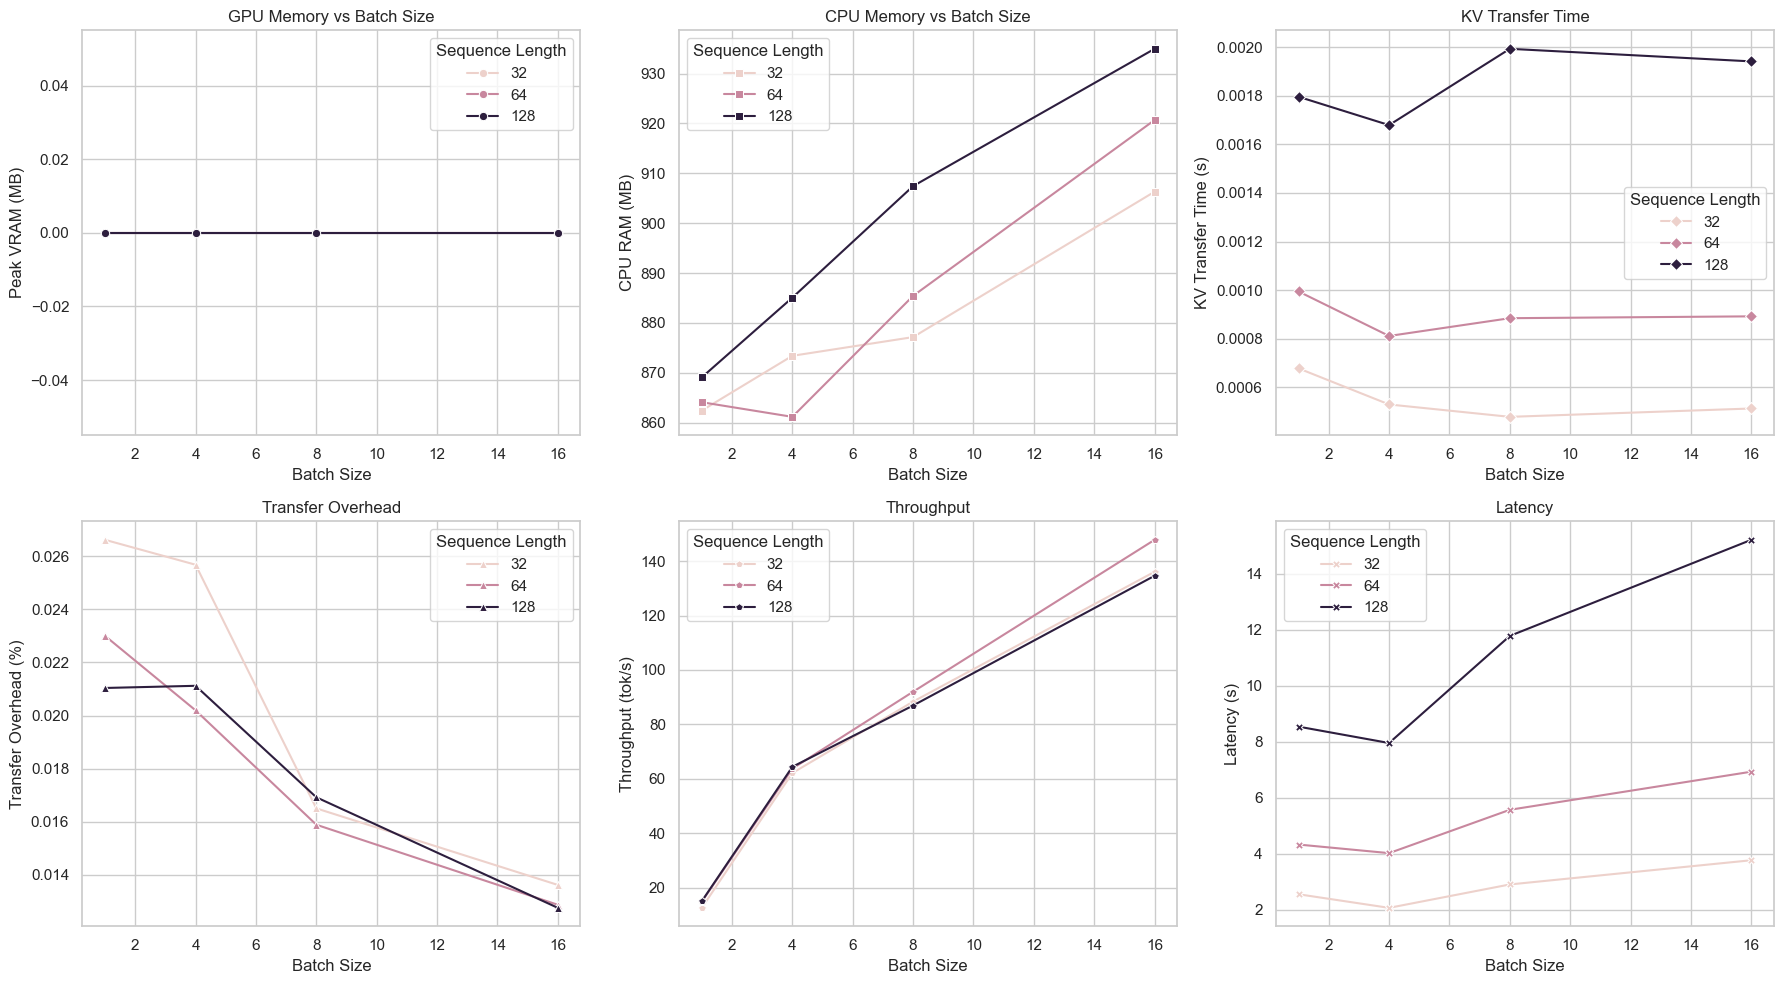

In [32]:
# Generate DejaVu performance graphs
plot_dejavu_results(df_dejavu_results)

BASELINE VS DEJAVU

This section merges the baseline and DejaVu benchmark results to create a unified comparison table.

We compute derived metrics such as:
- Latency Slowdown: Ratio of DejaVu latency to baseline latency.
- Throughput Change: Percentage difference in token generation throughput.
- CPU RAM Increase: Additional CPU memory used by the DejaVu pipeline.

This table provides a consolidated view of the performance trade-offs between conventional GPU-resident KV caching and DejaVu-style KV cache streaming.

In [34]:
df_baseline_cmp = df_baseline_results.copy()
df_dejavu_cmp = df_dejavu_results.copy()

comparison_table = pd.merge(
    df_baseline_cmp,
    df_dejavu_cmp,
    on=["Batch Size", "Sequence Length"],
    suffixes=("_Baseline", "_DejaVu")
)

# Latency comparison
comparison_table["Latency Slowdown (x)"] = (
    comparison_table["Latency (s)_DejaVu"] /
    comparison_table["Latency (s)_Baseline"]
)

# Throughput comparison
comparison_table["Throughput Change (%)"] = (
    (comparison_table["Throughput (tok/s)_DejaVu"] - comparison_table["Throughput (tok/s)_Baseline"]) /
    comparison_table["Throughput (tok/s)_Baseline"]
) * 100

# Handle CPU RAM column safely
if "CPU RAM (MB)_DejaVu" in comparison_table.columns:
    cpu_ram_dejavu_col = "CPU RAM (MB)_DejaVu"
elif "CPU RAM (MB)" in comparison_table.columns:
    cpu_ram_dejavu_col = "CPU RAM (MB)"
else:
    cpu_ram_dejavu_col = None

if "CPU RAM (MB)_Baseline" in comparison_table.columns and cpu_ram_dejavu_col is not None:
    comparison_table["CPU RAM Increase (MB)"] = (
        comparison_table[cpu_ram_dejavu_col] - comparison_table["CPU RAM (MB)_Baseline"]
    )
elif cpu_ram_dejavu_col is not None:
    comparison_table["CPU RAM Increase (MB)"] = comparison_table[cpu_ram_dejavu_col]
else:
    comparison_table["CPU RAM Increase (MB)"] = 0

# Handle KV cache column safely
if "KV Cache (MB)_DejaVu" in comparison_table.columns:
    kv_cache_dejavu_col = "KV Cache (MB)_DejaVu"
elif "KV Cache (MB)" in comparison_table.columns:
    kv_cache_dejavu_col = "KV Cache (MB)"
else:
    kv_cache_dejavu_col = None

# Build final display table
final_cols = [
    "Batch Size",
    "Sequence Length",
    "Latency (s)_Baseline",
    "Latency (s)_DejaVu",
    "Latency Slowdown (x)",
    "Throughput (tok/s)_Baseline",
    "Throughput (tok/s)_DejaVu",
    "Throughput Change (%)",
    "KV Transfer Time (s)",
    "Transfer Overhead (%)",
    "CPU RAM Increase (MB)"
]

if cpu_ram_dejavu_col is not None:
    final_cols.append(cpu_ram_dejavu_col)

if kv_cache_dejavu_col is not None:
    final_cols.append(kv_cache_dejavu_col)

comparison_table[final_cols].round(3)

,Batch Size,Sequence Length,Latency (s)_Baseline,Latency (s)_DejaVu,Latency Slowdown (x),Throughput (tok/s)_Baseline,Throughput (tok/s)_DejaVu,Throughput Change (%),KV Transfer Time (s),Transfer Overhead (%),CPU RAM Increase (MB),CPU RAM (MB),KV Cache (MB)_DejaVu
0,1,32,2.419,2.547,1.053,13.230,12.564,-5.033,0.001,0.027,862.430,862.430,0.0
1,1,64,3.334,4.324,1.297,19.195,14.802,-22.888,0.001,0.023,864.105,864.105,0.0
2,1,128,7.009,8.538,1.218,18.263,14.992,-17.913,0.002,0.021,869.086,869.086,0.0
3,4,32,2.031,2.061,1.015,63.024,62.100,-1.465,0.001,0.026,873.410,873.410,0.0
4,4,64,4.002,4.017,1.004,63.968,63.731,-0.370,0.001,0.020,861.172,861.172,0.0
5,4,128,8.897,7.952,0.894,57.548,64.383,11.877,0.002,0.021,885.070,885.070,0.0
6,8,32,3.388,2.897,0.855,75.557,88.356,16.939,0.000,0.017,877.164,877.164,0.0
7,8,64,6.988,5.566,0.797,73.270,91.989,25.548,0.001,0.016,885.430,885.430,0.0
8,8,128,15.870,11.781,0.742,64.523,86.921,34.714,0.002,0.017,907.441,907.441,0.0
9,16,32,5.731,3.763,0.656,89.331,136.073,52.325,0.001,0.014,906.320,906.320,0.0


 Phase 2 Performance Plots:

This section generates visual comparisons between the Baseline and DejaVu systems.

The plots illustrate how key performance metrics vary with different batch sizes and sequence lengths, including latency, throughput, KV transfer time, transfer overhead, CPU memory usage, and KV cache size.

These visualizations help analyze the performance trade-offs introduced by DejaVu-style KV cache streaming.

In [35]:
def plot_phase2_results(df_baseline, df_dejavu):
    baseline = df_baseline.copy()
    dejavu = df_dejavu.copy()

    baseline["System"] = "Baseline"
    dejavu["System"] = "DejaVu"

    combined = pd.concat([baseline, dejavu], ignore_index=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=combined, x="Batch Size", y="Latency (s)",
        hue="System", style="Sequence Length", marker="o", ax=axes[0, 0]
    )
    axes[0, 0].set_title("Latency vs Batch Size")

    sns.lineplot(
        data=combined, x="Batch Size", y="Throughput (tok/s)",
        hue="System", style="Sequence Length", marker="s", ax=axes[0, 1]
    )
    axes[0, 1].set_title("Throughput vs Batch Size")

    sns.lineplot(
        data=dejavu, x="Batch Size", y="KV Transfer Time (s)",
        hue="Sequence Length", marker="D", ax=axes[0, 2]
    )
    axes[0, 2].set_title("KV Transfer Time")

    sns.lineplot(
        data=dejavu, x="Batch Size", y="Transfer Overhead (%)",
        hue="Sequence Length", marker="^", ax=axes[1, 0]
    )
    axes[1, 0].set_title("Transfer Overhead (%)")

    sns.lineplot(
        data=dejavu, x="Batch Size", y="CPU RAM (MB)",
        hue="Sequence Length", marker="p", ax=axes[1, 1]
    )
    axes[1, 1].set_title("CPU RAM Usage")

    sns.lineplot(
        data=dejavu, x="Batch Size", y="KV Cache (MB)",
        hue="Sequence Length", marker="X", ax=axes[1, 2]
    )
    axes[1, 2].set_title("KV Cache Size")

    plt.tight_layout()
    plt.show()

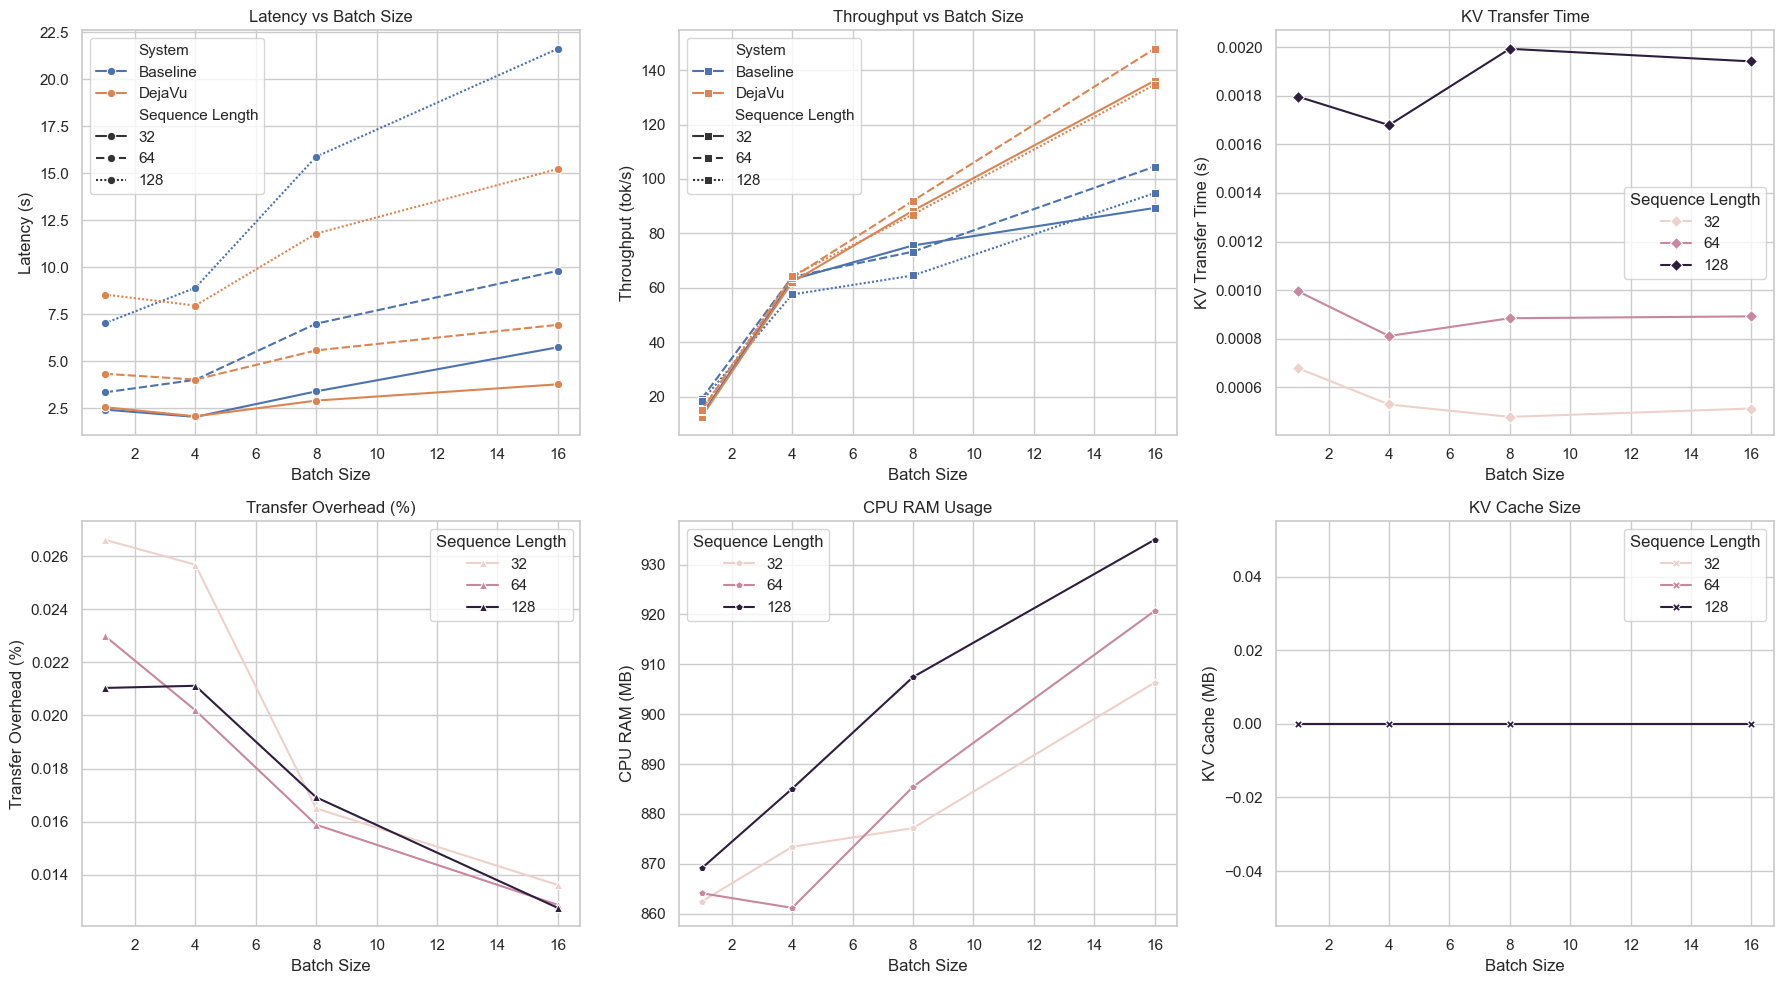

In [36]:
plot_phase2_results(df_baseline_results, df_dejavu_results)

DEJAVU LATENCY SLOWDOWN ANALYSIS:

This plot shows the relative latency slowdown of the DejaVu pipeline compared to the baseline system across different batch sizes and sequence lengths.

The slowdown metric represents the ratio of DejaVu latency to baseline latency, helping highlight the performance impact of KV cache streaming.

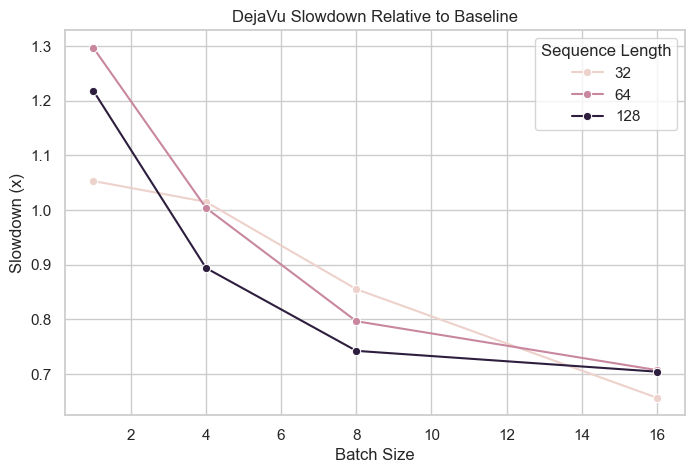

In [37]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=comparison_table,
    x="Batch Size",
    y="Latency Slowdown (x)",
    hue="Sequence Length",
    marker="o"
)
plt.title("DejaVu Slowdown Relative to Baseline")
plt.ylabel("Slowdown (x)")
plt.show()